# Manga character generation with DDPM

In this implementation, I use Denoising Diffusion Probabilistic Models (DDPM) to generate manga-like faces.

Diffusion models are generative models that can generate high-quality data (much better than VAEs) without the instability and training complications of GANs.
Their main drawback is that the generation process is expensive, requiring multiple steps through a deep neural network.

Diffusion models are the main component of many modern systems for generative AI.

## Denoising Diffusion Probabilistic Models (DDPM)

DDPM model a stochastic process in which noise is gradually added to a starting sample $x_0$. The forward process $x_0 \to x_1 \to \dots \to x_T$ is modeled exactly. Then, the reverse process $x_T \to x_{T-1} \to \dots \to x_0$ is approximated thanks to a deep neural network trained for denoising.

![DDPM process](https://lilianweng.github.io/posts/2021-07-11-diffusion-models/DDPM.png)

Note that, if taken $T$ large enough, $x_T$ can be assumed to be pure noise, and it can be sampled.
The result of the reverse process is that it is possible to sample $x_0$ as if it was coming from the same unknown distribution represented by the training set.

## Setup

Let's start by importing the libraries, and by unpacking the training data into the Colab space.

In [1]:
import torch
import torch.nn.functional as F
import torchvision
import matplotlib.pyplot as plt
import os

URL = "https://drive.google.com/file/d/1kNvYNK5HGSUSJHhyosdnwhT6TTMB9URz/view?usp=sharing"

!gdown --fuzzy -O- "$URL" | tar xzf - && echo OK

Downloading...
From (original): https://drive.google.com/uc?id=1kNvYNK5HGSUSJHhyosdnwhT6TTMB9URz
From (redirected): https://drive.google.com/uc?id=1kNvYNK5HGSUSJHhyosdnwhT6TTMB9URz&confirm=t&uuid=3c84ae27-0393-4ba3-8a8d-4240779e3980
To: <_io.BufferedWriter name='<stdout>'>
100% 40.4M/40.4M [00:01<00:00, 38.9MB/s]
OK


## Dataset

The training images are a subset of the dataset published [here](https://www.kaggle.com/aadilmalik94/animecharacterfaces). In total, there are 12000 images, each one already scaled down to $64 \times 64$ pixels. The simple `ImageFolder` class in the `torchvision` library can be used to load the dataset.  The dataset will pair the images with a useless label, which we can just ignore.

To reduce computation we will further reduce the size of the images to $32 \times 32$ pixels.  If you have more time, you can try also with the original size.

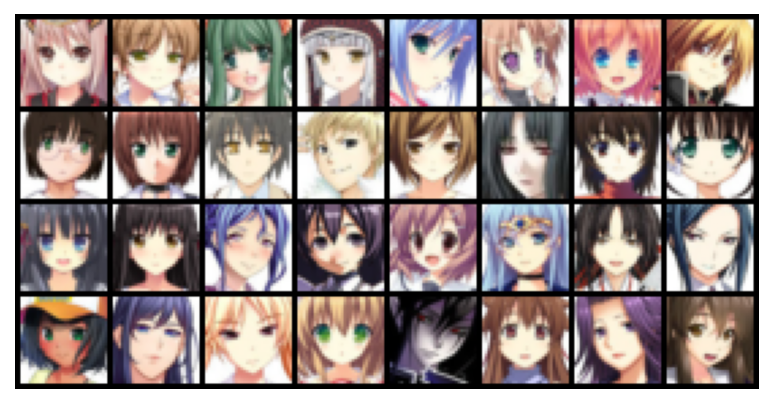

In [ ]:
HEIGHT = WIDTH = 32
BATCH_SIZE = 32

transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize((HEIGHT, WIDTH)),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(0.5, 0.5) # scales to be in range [-1,1] instead of [0,1]
])

# Define the dataset and the data loader
train_set = torchvision.datasets.ImageFolder("manga/train", transform=transform) # it puts labels on images in subfolders automatically, even if there is only one class
loader = torch.utils.data.DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,
                                     drop_last=True, num_workers=2)

def show_faces(faces):
    g = torchvision.utils.make_grid(faces, normalize=True, value_range=(-1, 1))
    plt.figure(dpi=150)
    plt.imshow(g.permute(1, 2, 0).detach().cpu())
    plt.axis("off")
    plt.show()

batch, labels = next(iter(loader))  # Labels are ignored
show_faces(batch)

### Forward diffusion process

During training the forward process is used to add noise to training images. This is done in multiple time steps. At time $t = 0$ there is the original image without noise. At the last time step $t = T$ the image is replaced by pure Gaussian noise with zero mean and unit variance. To get to that point the image is combined with a small amount of Gaussian noise:


$$x_{t} = \sqrt{1 - \beta_t} x_{t-1} + \sqrt{\beta_t}\epsilon$$

where $\epsilon$ is drawn from a Gaussian with zero mean and unit variance. The scalar parameters $\beta_1, \beta_2, \dots, \beta_{T-1}$ define the "variance schedule" of the process. In fact, adding the same amount of noise at each step is not optimal. Instead, it is more efficient to add more noise close to the end of the forward process, when the image is already very noisy.

In the following it will be useful to define also:
$$\alpha_t = 1 - \beta_t, \; \; \bar\alpha_t = \prod_{i=1}^t \alpha_t.$$

Therefore,
$$x_{t} = \sqrt{\alpha_t} x_{t-1} + \sqrt{1 - \alpha_t}\epsilon$$

In [3]:
DEVICE = ("cuda" if torch.cuda.is_available() else "cpu")
print(DEVICE)

cuda


In [4]:
TIMESTEPS = 300
beta = torch.linspace(0.0001, 0.02, TIMESTEPS, device=DEVICE)
alpha = 1 - beta
alpha_bar = torch.cumprod(alpha, axis=0)

## Gaussians are nice distributions

The sum of two Gaussian variables is another Gaussian variable, with the sum of means as mean, and the sum of variances as variance.
$$z_t \sim N(\mu_t, \sigma_t^2) \implies \sum_t z_t \sim N(\sum_t \mu_t, \sum_t \sigma_t^2)$$.

Thanks to this property, we can sample $x_t$ by skipping intermediate steps (this will be used for training):
$$\begin{split}
x_t
&= \sqrt{\alpha_{t}} x_{t-1} + \sqrt{1 - \alpha_{t}}\epsilon \\
&= \sqrt{\alpha_{t} \alpha_{t-1}} x_{t-2} + \sqrt{\alpha_{t-1}(1 - \alpha_{t})}\epsilon + \sqrt{1 - \alpha_{t-1}}\epsilon
= \sqrt{\alpha_{t} \alpha_{t-1}} x_{t-2} + \sqrt{1 - \alpha_{t}\alpha_{t-1}}\epsilon \\
&= \dots \\
&= \sqrt{\prod_t\alpha_t} x_0 + \sqrt{1 - \prod_t\alpha_t}\epsilon \\
&=  \sqrt{\bar\alpha_t} x_0 + \sqrt{1 - \bar\alpha_t}\epsilon.
\end{split}$$
Note that each step includes its own noise $\epsilon$, but they can be collapsed into a single random variable

In [ ]:
# Sample xt from x0
def q_sample(x0, t, noise=None):
    t = t.expand(x0.shape[0])
    if noise is None:
        noise = torch.randn_like(x0)

    xt = torch.sqrt(alpha_bar[t]).view(-1, 1, 1, 1) * x0 + torch.sqrt(1 - alpha_bar[t]).view(-1, 1, 1, 1) * noise
    return xt

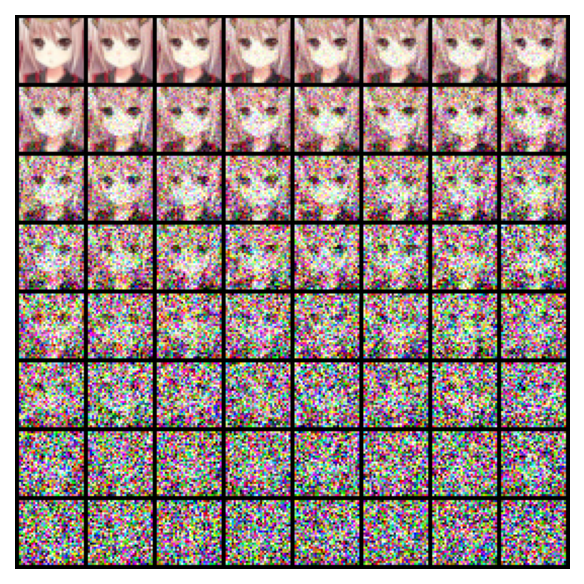

In [6]:
x = batch[0:1].to(DEVICE)
t = torch.linspace(0, TIMESTEPS - 1, 64).long()
x_noisy = q_sample(x.repeat(t.shape[0], 1, 1, 1), t)
show_faces(x_noisy)

## The neural network

To reverse the process $x_{t-1}$ has to the sampled from $x_t$. This computation is not tractable, and has to be approximated with a neural network.  More precisely, the neural network will take $x_t$ and $t$ as input, and will estimate the noise $\epsilon$:

$$\epsilon \sim \epsilon_\theta(x_t, t).$$

This is the same architecture described in the original paper. It is a Unet-like CNN with residual and skip connections, and with attention mechanism. It is provided in the `unet.py` module.   

In [ ]:
import unet

# Parameters:
# - number of features;
# - multipliers for features at each stage;
# - number of channels.
model = unet.Unet(32, (1, 2, 4, 8), 3) # model estimates the noise, sort of est. (xt-x0)
print(model)
model.to(DEVICE)
ps = sum(p.numel() for p in model.parameters())
print(f"{ps:,d} parameters")
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

Unet(
  (init_conv): Conv2d(3, 32, kernel_size=(1, 1), stride=(1, 1))
  (time_mlp): Sequential(
    (0): SinusoidalPositionEmbeddings()
    (1): Linear(in_features=32, out_features=128, bias=True)
    (2): GELU(approximate='none')
    (3): Linear(in_features=128, out_features=128, bias=True)
  )
  (downs): ModuleList(
    (0): ModuleList(
      (0-1): 2 x ResnetBlock(
        (mlp): Sequential(
          (0): SiLU()
          (1): Linear(in_features=128, out_features=64, bias=True)
        )
        (block1): Block(
          (proj): WeightStandardizedConv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (norm): GroupNorm(4, 32, eps=1e-05, affine=True)
          (act): SiLU()
        )
        (block2): Block(
          (proj): WeightStandardizedConv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (norm): GroupNorm(4, 32, eps=1e-05, affine=True)
          (act): SiLU()
        )
        (res_conv): Identity()
      )
      (2): Residual(
   

## Training algorithm

The training algorithm for DDPM is very simple: take a batch of training samples, pick random time indices, generate the noisy samples, use the network to estimate the noise, and compare the actual and estimated noise.

The derivation of the loss function is cumbersome. Empirically, the following simplified loss works well:

$$\mathcal L = \|\epsilon - \epsilon_\theta(x_t, t)\|^2.$$

This is the algorithm taken from the original paper.
![training algorithm](https://huggingface.co/blog/assets/78_annotated-diffusion/training.png)

A small variation is introduced -  using the L1 loss instead of L2 for stability reasons.


In [ ]:
EPOCHS = 20

step = 0

if os.path.exists("unet.pt"):
    # Load the pre-trained model if there is a saved file
    model.load_state_dict(torch.load("unet.pt", map_location=DEVICE))
else:
    for epoch in range(EPOCHS):
        for x0, labels in loader:
            optimizer.zero_grad()
            x0 = x0.to(DEVICE)

            t = torch.randint(0, TIMESTEPS, (BATCH_SIZE,), device=DEVICE).long()

            noise = torch.randn_like(x0)
            xt = q_sample(x0, t, noise=noise) # noisy image
            predicte_noise = model(xt, t)

            optimizer.zero_grad()
            loss = F.l1_loss(noise, predicte_noise)
            loss.backward()
            optimizer.step()

            step += 1
            if step % 100 == 0:
                print(f"{step} [{epoch}] {loss.item():.4f}")

torch.save(model.state_dict(), "unet.pt")

## Sampling

After training, the model is ready to generate new images.

Start from $x_T$ sampled from a Gaussian distribution, and sample backward to $x_0$.

The sampling algorithm is:
![sampling algorithm](https://huggingface.co/blog/assets/78_annotated-diffusion/sampling.png)

Note that $z_\theta(x_t, t)$ is the estimated noise for the full $x_0 \to x_t$ process, and it must be properly scaled to obtain $x_{t-1}$. The backward process also requires a seprate variance schedule $\sigma_t^2$.  Here we will use the following:
$$ \sigma_t^2 = \frac{1 - \bar\alpha_{t-1}}{1 - \bar\alpha_t} \beta_t.$$

Note that in the last step the process has no noise.

In [19]:
sigma = beta * (1 - alpha_bar / alpha) / (1 - alpha_bar) # it's squared
sigma[0] = 0

@torch.no_grad()
def p_sample(model, x, t):
    b = beta[t].view(-1, 1, 1, 1)
    a = alpha[t].view(-1, 1, 1, 1)
    abar = alpha_bar[t].view(-1, 1, 1, 1)
    s = sigma[t].view(-1, 1, 1, 1)

    # Implement the formula.
    predicted_noise = model(x, t)
    model_mean = (1 / torch.sqrt(a)) * (x - ((1 - a)/(torch.sqrt(1 - abar))) * predicted_noise)
    noise = torch.randn_like(x) if t[0] > 0 else torch.zeros_like(x)
    x_prev = model_mean + torch.sqrt(s) * noise
    return x_prev

def sample(model, shape):
    b = shape[0]
    img = torch.randn(shape, device=DEVICE)
    imgs = []

    for i in range(TIMESTEPS - 1, -1, -1):
        t = torch.full((b,), i, device=DEVICE).long()
        img = p_sample(model, img, t)
        imgs.append(img.cpu())
    return imgs

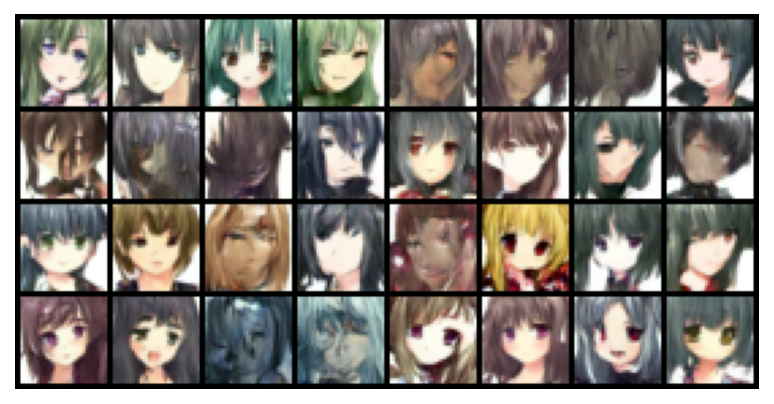

In [21]:
generated = sample(model, (BATCH_SIZE, 3, HEIGHT, WIDTH))
show_faces(generated[299])

# Improvements

The model should be trained for much more epochs and with a smaller learning rate. On more data as well.

Instead of L1 loss, use L2 loss like in the original paper.